# User distribution by country

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import plotly.express as px

# 1. Setup your database engine
connection_string = (
    "mssql+pyodbc://@./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
engine = create_engine(connection_string)

# 2. SQL Query to get total users grouped by country
query = """
SELECT 
    country,
    COUNT(user_id) AS total_users
FROM [dbo].[users]
GROUP BY 
    country;
"""

try:
    # 3. Pull the data into a DataFrame
    with engine.connect() as con:
        df_country = pd.read_sql(query, con)
    
    # 4. Generate the interactive geographic map plot
    # locationmode='country names' matches your string database data directly to the map shapes
    fig = px.choropleth(
        df_country,
        locations="country",
        locationmode="country names",
        color="total_users",
        hover_name="country",
        hover_data={"country": False, "total_users": True}, # Displays count label cleanly on hover
        color_continuous_scale=px.colors.sequential.Plasma,
        labels={'total_users': 'Active Users'},
        title="<b>Global User Distribution by Country</b>"
    )
    
    # 5. Clean up the map layout options
    fig.update_layout(
        title_font_size=20,
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular' # Standard global layout map projection
        )
    )
    
    # Render the plot window
    fig.show()

except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\SajayN\AppData\Local\Temp\ipykernel_49224\99235538.py:24: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  with engine.connect() as con:
C:\Users\SajayN\AppData\Local\Temp\ipykernel_49224\99235538.py:29: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [5]:
pip install pandas plotly pyodbc


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import warnings
import pandas as pd
import plotly.express as px
from sqlalchemy import create_engine
from sqlalchemy.exc import SAWarning

# Suppress the harmless version warning from SQLAlchemy
warnings.filterwarnings("ignore", category=SAWarning)

# 1. Connection Engine
connection_url = (
    "mssql+pyodbc://./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&"
    "trusted_connection=yes"
)
engine = create_engine(connection_url)

# 2. SQL Query
query = """
SELECT 
    country,
    COUNT(user_id) AS total_users
FROM [dbo].[Users]
GROUP BY 
    country
ORDER BY 
    total_users DESC;
"""

df = pd.read_sql(query, engine)

# 3. Country ISO Dictionary Mapping
country_iso_map = {
    'United States': 'USA', 'USA': 'USA',
    'India': 'IND', 'India ': 'IND',
    'Canada': 'CAN',
    'United Kingdom': 'GBR', 'UK': 'GBR',
    'Australia': 'AUS',
}
df['country_iso'] = df['country'].map(country_iso_map).fillna(df['country'])

# 4. Create Map
fig = px.choropleth(
    df,
    locations="country_iso",           
    locationmode="ISO-3",              
    color="total_users",               
    hover_name="country",              
    color_continuous_scale="ylgn",    
    labels={'total_users': 'Total Users'}
)

# 5. Fixed Layout Settings (Removed all 'center' anchors for yanchor)
fig.update_layout(
    title={
        'text': "Global User Distribution by Country",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',  
        'font': {'size': 20, 'weight': 'bold', 'color': '#111111'}
    },
    geo=dict(
        showframe=False,               
        showcoastlines=True,           
        coastlinecolor="#777777",
        projection_type='equirectangular', 
        bgcolor='#FFFFFF'              
    ),
    margin={"r":0,"t":70,"l":0,"b":0},
    coloraxis_colorbar=dict(
        title="User Count",
        thicknessmode="pixels", thickness=15,
        lenmode="pixels", len=300,
        yanchor="middle", # Fixed: Changed from 'center' to 'middle'
        y=0.5,
        ticks="outside"
    )
)

# 6. Show Plot
fig.show()

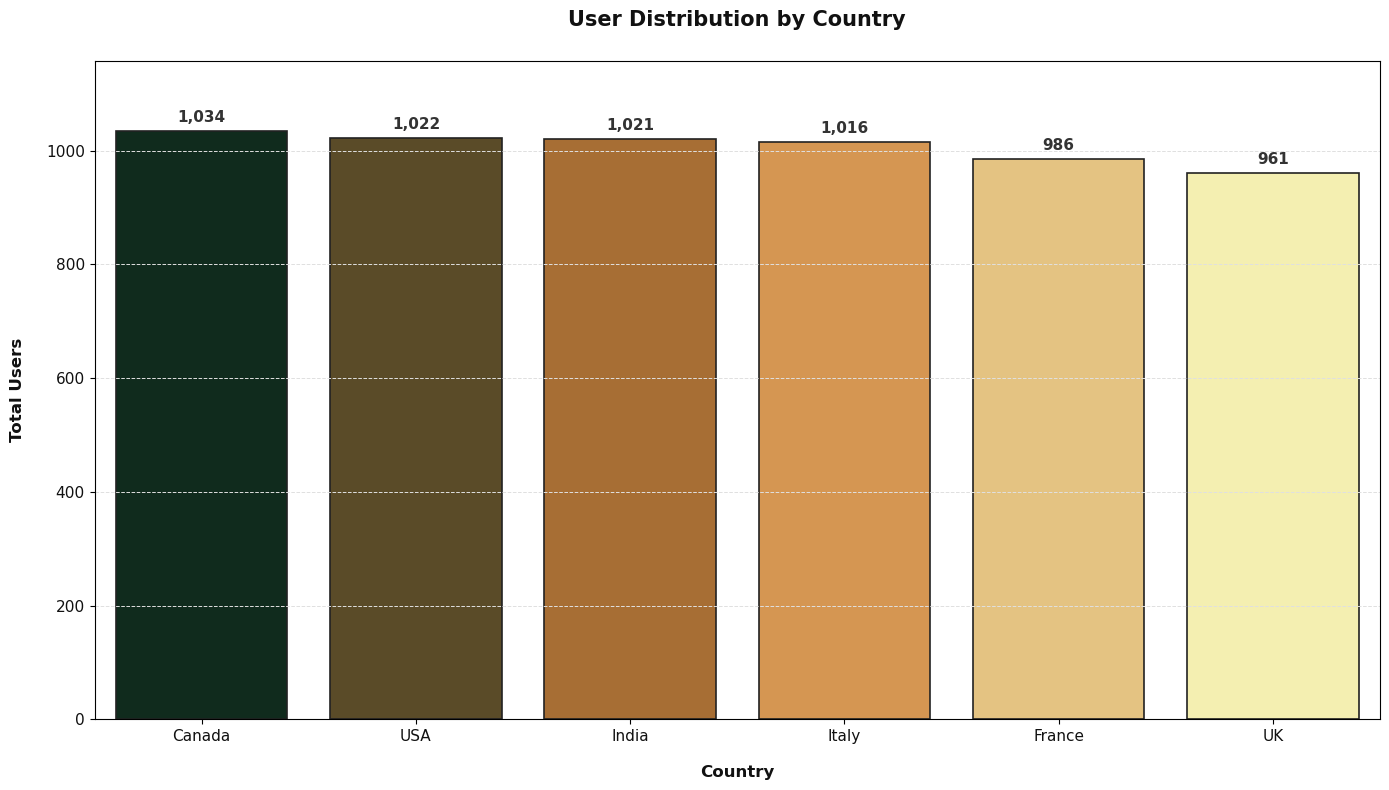

In [12]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.exc import SAWarning
import matplotlib.colors as mcolors

# Suppress harmless SQLAlchemy version warnings
warnings.filterwarnings("ignore", category=SAWarning)

# 1. Connection Engine
connection_url = (
    "mssql+pyodbc://./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&"
    "trusted_connection=yes"
)
engine = create_engine(connection_url)

# 2. SQL Query: Fetching user distribution by country
query = """
SELECT 
    country,
    COUNT(user_id) AS total_users
FROM [dbo].[Users]
GROUP BY 
    country
ORDER BY 
    total_users DESC;
"""

df = pd.read_sql(query, engine)

# 3. Create a Highly Contrasting Left-to-Right Step Gradient
# Leftmost (index 0) is the darkest green, blending smoothly to the rightmost lightest yellow
bar_colors = []
if not df.empty:
    num_bars = len(df)
    
    # Precise anchor points matching your request
    darkest_left = mcolors.to_rgb('#0B2F1D')   # 1. Darkest Forest Green
    mid_saffron  = mcolors.to_rgb('#E67E22')   # 2. Mid transition warm orange/saffron
    lightest_rt  = mcolors.to_rgb('#FFF9A6')   # 3. Lightest Canary Yellow
    
    if num_bars > 1:
        for i in range(num_bars):
            # Proportional progress from left (0.0) to right (1.0)
            progress = i / (num_bars - 1)
            
            # Split blending halfway to force a clean dark -> warm -> light yellow transition
            if progress < 0.5:
                # Scale from Darkest Green to Saffron
                w = progress / 0.5
                r = darkest_left[0] + (mid_saffron[0] - darkest_left[0]) * w
                g = darkest_left[1] + (mid_saffron[1] - darkest_left[1]) * w
                b = darkest_left[2] + (mid_saffron[2] - darkest_left[2]) * w
            else:
                # Scale from Saffron to Lightest Yellow
                w = (progress - 0.5) / 0.5
                r = mid_saffron[0] + (lightest_rt[0] - mid_saffron[0]) * w
                g = mid_saffron[1] + (lightest_rt[1] - mid_saffron[1]) * w
                b = mid_saffron[2] + (lightest_rt[2] - mid_saffron[2]) * w
                
            bar_colors.append(mcolors.to_hex((r, g, b)))
    else:
        bar_colors = [mcolors.to_hex(darkest_left)]

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the VERTICAL bar plot with explicit left-to-right color stepping
sns.barplot(
    x='country', 
    y='total_users', 
    data=df, 
    palette=bar_colors,
    hue='country',
    legend=False,
    edgecolor='#222222',  # Crisp dark borders to isolate the shifting gradient panels
    linewidth=1.2
)

# 5. Clean Dashboard Layout Styling
plt.title('User Distribution by Country', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Country', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Total Users', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7, axis='y') 

# Dynamically adjust Y-axis ceiling limit to give breathing room for text labels
if not df.empty:
    plt.ylim(0, df['total_users'].max() * 1.12) 

# 6. Clean Vertical Bar Data Labels (Formatted with commas)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    user_count = int(df.iloc[i]['total_users'])
    
    label_text = f"{user_count:,}"
    
    ax.text(
        p.get_x() + p.get_width() / 2, 
        height + (df['total_users'].max() * 0.01), 
        label_text, 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()